# 01 — Exploratory Data Analysis

**Audience:** anyone new to the dataset. Answers: what's in here, what's missing, what's broken?

Reads from MongoDB. The backend writes control inputs directly to the same collection, so there's no API call here.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from etl.config import load_config
from etl.extract import iter_documents
from etl.transform import to_dataframe, add_derived_features, detect_outliers
from etl.load import get_collection

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
config = load_config()
from etl.broadcasts import broadcasts_to_dataframe, fetch_broadcasts


In [2]:
collection = get_collection(config.mongo_uri, config.mongo_db, config.mongo_collection)
rows = list(iter_documents(collection))
df = add_derived_features(to_dataframe(rows))
print(f'Loaded {len(df):,} rows spanning {df.index.min()} -> {df.index.max()}')
df.head()

Loaded 7,287 rows spanning 2026-05-20 13:48:37.581000+00:00 -> 2026-05-26 13:27:30.875000+00:00


,clientTimestamp,steering,throttle,brake,buttons,hats,source,sessionId,_class,movement,idle,latency_ms,abs_steering,throttle_brake_overlap,steering_delta,throttle_delta,sample_dt_ms
recorded_at,,,,,,,,,,,,,,,,,
2026-05-20 13:48:37.581000+00:00,1779284917153,0.00,1.0,1.0,[],[],keyboard,a4409177-5cf1-17dd-da4c-badacfbdf19a,be.ucll.itintegrationproject.NL_14_backend.mod...,0.0,False,428.0,0.00,1,0.00,0.0,NaN
2026-05-20 13:48:38.118000+00:00,1779284917684,0.04,1.0,1.0,[],[],keyboard,a4409177-5cf1-17dd-da4c-badacfbdf19a,be.ucll.itintegrationproject.NL_14_backend.mod...,0.0,False,434.0,0.04,1,0.04,0.0,537.0
2026-05-20 13:48:38.318000+00:00,1779284917879,0.28,1.0,1.0,[],[],keyboard,a4409177-5cf1-17dd-da4c-badacfbdf19a,be.ucll.itintegrationproject.NL_14_backend.mod...,0.0,False,439.0,0.28,1,0.24,0.0,200.0
2026-05-20 13:48:38.519000+00:00,1779284918080,0.52,1.0,1.0,[],[],keyboard,a4409177-5cf1-17dd-da4c-badacfbdf19a,be.ucll.itintegrationproject.NL_14_backend.mod...,0.0,False,439.0,0.52,1,0.24,0.0,201.0
2026-05-20 13:48:38.774000+00:00,1779284918309,0.80,1.0,1.0,[],[],keyboard,a4409177-5cf1-17dd-da4c-badacfbdf19a,be.ucll.itintegrationproject.NL_14_backend.mod...,0.0,False,465.0,0.80,1,0.28,0.0,255.0


## 1. Data quality
Counts of suspicious rows. These should be near-zero in a healthy dataset.

In [3]:
quality = detect_outliers(df)
pd.Series(quality).to_frame('count')

,count
rows_total,7287
rows_missing_session,0
rows_negative_latency,2404
rows_huge_latency,4
rows_steering_out_of_range,0
rows_throttle_out_of_range,1305
rows_brake_out_of_range,9
rows_idle,2254


## 2. Source breakdown
How is input arriving — physical wheel or keyboard fallback?

source
keyboard    5852
wheel       1435
Name: count, dtype: int64


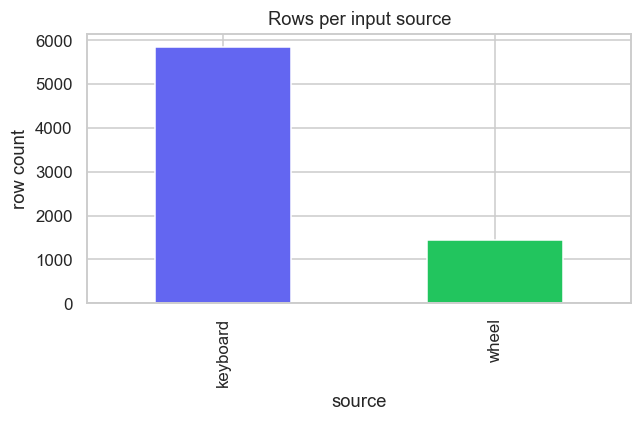

In [4]:
source_counts = df['source'].value_counts()
print(source_counts)
fig, ax = plt.subplots(figsize=(6, 4))
source_counts.plot.bar(ax=ax, color=['#6366f1', '#22c55e'])
ax.set_title('Rows per input source')
ax.set_ylabel('row count')
plt.tight_layout()

## 3. Distributions of the three axes
Are users actually using the full range, or clustered around neutral?

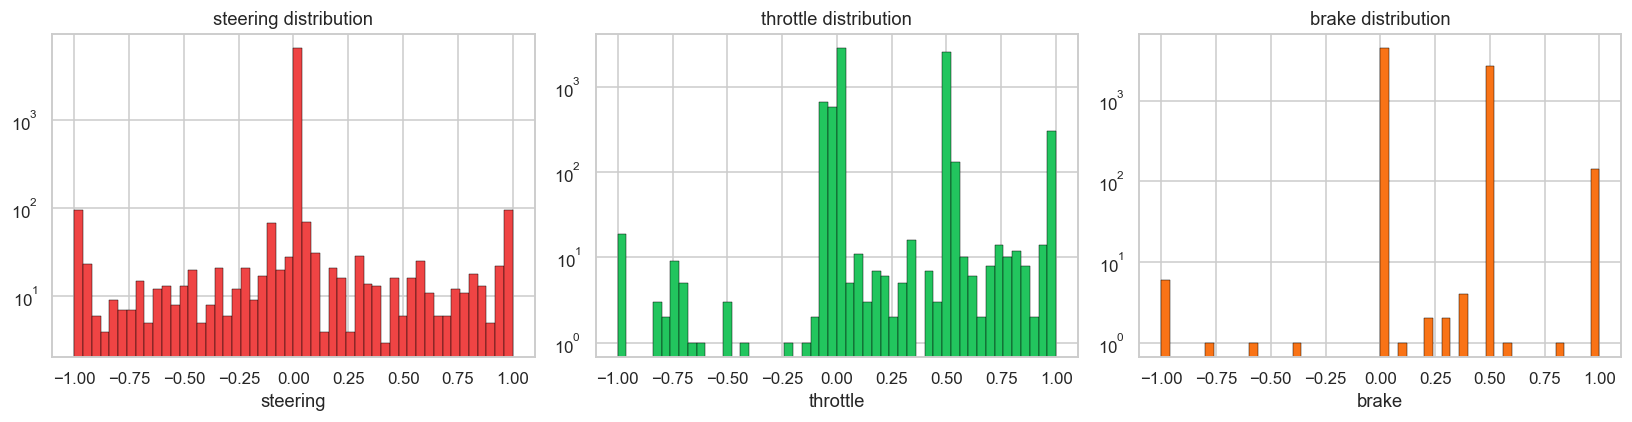

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes, ['steering', 'throttle', 'brake'], ['#ef4444', '#22c55e', '#f97316']):
    ax.hist(df[col], bins=50, color=color, edgecolor='black', linewidth=0.3)
    ax.set_title(f'{col} distribution')
    ax.set_xlabel(col)
    ax.set_yscale('log')
plt.tight_layout()

## 4. Correlation between axes
Throttle and brake should be near-zero correlated for good drivers; high overlap is a coaching signal.

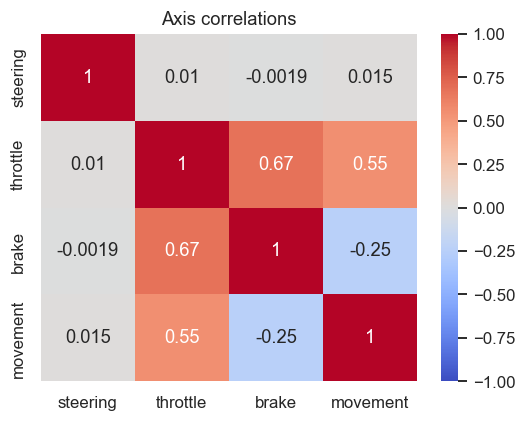

In [6]:
corr = df[['steering', 'throttle', 'brake', 'movement']].corr()
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Axis correlations')
plt.tight_layout()

## 5. Activity over time
Rows per minute over the whole dataset — usage pattern.

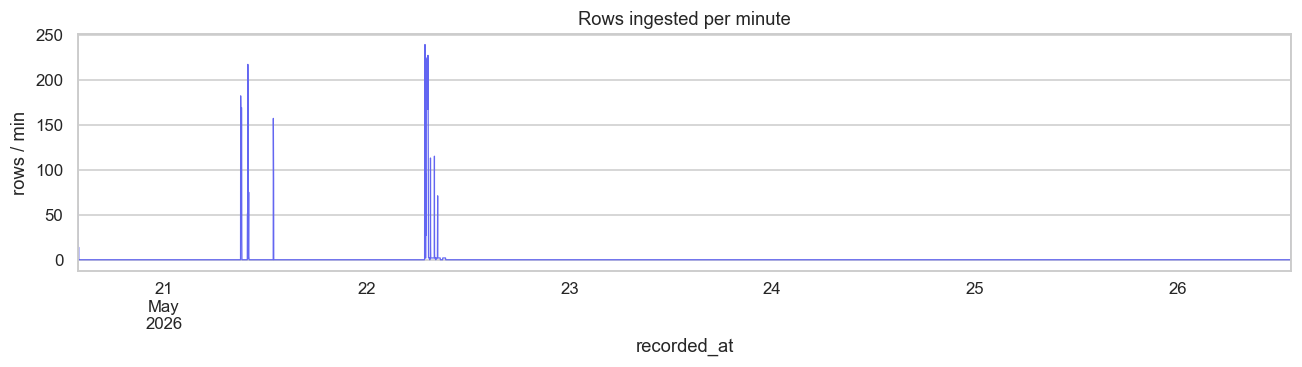

In [7]:
per_minute = df.resample('1min').size()
fig, ax = plt.subplots(figsize=(12, 3.5))
per_minute.plot(ax=ax, color='#6366f1', linewidth=0.8)
ax.set_title('Rows ingested per minute')
ax.set_ylabel('rows / min')
plt.tight_layout()

## 6. Hour-of-day usage heatmap

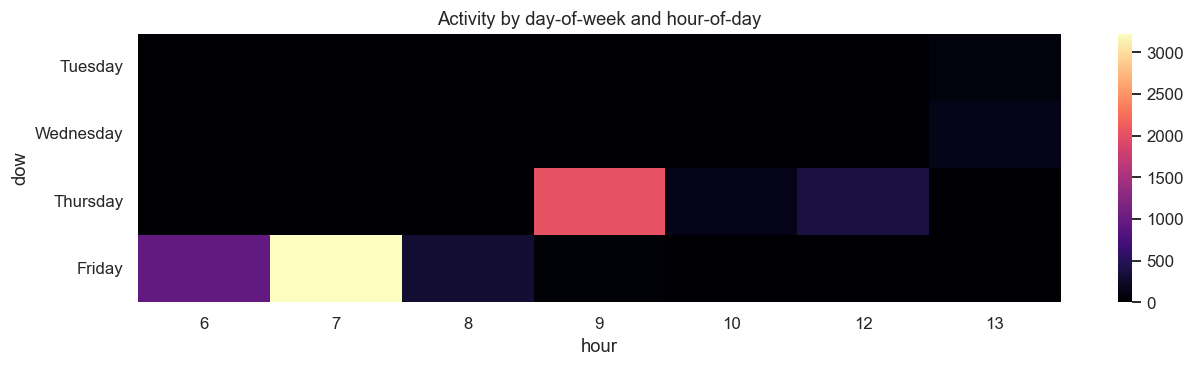

In [8]:
local = df.copy()
local['hour'] = local.index.hour
local['dow'] = local.index.day_name()
heat = local.groupby(['dow', 'hour']).size().unstack(fill_value=0)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heat = heat.reindex([d for d in day_order if d in heat.index])
fig, ax = plt.subplots(figsize=(12, 3.5))
sns.heatmap(heat, cmap='magma', ax=ax)
ax.set_title('Activity by day-of-week and hour-of-day')
plt.tight_layout()

## 7. Raw broadcast vs filtered logs

The backend broadcasts each raw frame to the ESP32 over WebSocket and (when
enabled) also persists it to ``controller_broadcasts``. The ``control_inputs``
collection we've been looking at so far is the **filtered** version — after
quantize, dedup and pedal hysteresis. This section pulls both and quantifies
what the filter drops.


In [9]:
raw_rows = fetch_broadcasts(config.mongo_uri, config.mongo_db, config.mongo_broadcast_collection)
raw_df = broadcasts_to_dataframe(raw_rows)
print(f'Raw broadcasts: {len(raw_df):,} rows')
print(f'Filtered logs : {len(df):,} rows')
if len(raw_df):
    print(f'Persist ratio : {len(df)/len(raw_df):.1%}')
raw_df.head()

Raw broadcasts: 720 rows
Filtered logs : 7,287 rows
Persist ratio : 1012.1%


,clientTimestamp,axes,buttons,hats,source,sessionId,_class,raw_steering,raw_throttle,raw_brake
recorded_at,,,,,,,,,,
2026-05-26 13:27:06.327000+00:00,1779802025479,"[0.0, 1.0, 1.0]",[],[],keyboard,c244ad91-b713-bf01-1c7a-fa346e2caf8b,be.ucll.itintegrationproject.NL_14_backend.mod...,0.0,0.0,0.0
2026-05-26 13:27:06.327000+00:00,1779802025416,"[0.0, 1.0, 1.0]",[],[],keyboard,c244ad91-b713-bf01-1c7a-fa346e2caf8b,be.ucll.itintegrationproject.NL_14_backend.mod...,0.0,0.0,0.0
2026-05-26 13:27:06.333000+00:00,1779802025382,"[0.0, 1.0, 1.0]",[],[],keyboard,c244ad91-b713-bf01-1c7a-fa346e2caf8b,be.ucll.itintegrationproject.NL_14_backend.mod...,0.0,0.0,0.0
2026-05-26 13:27:06.334000+00:00,1779802025548,"[0.0, 1.0, 1.0]",[],[],keyboard,c244ad91-b713-bf01-1c7a-fa346e2caf8b,be.ucll.itintegrationproject.NL_14_backend.mod...,0.0,0.0,0.0
2026-05-26 13:27:06.334000+00:00,1779802025513,"[0.0, 1.0, 1.0]",[],[],keyboard,c244ad91-b713-bf01-1c7a-fa346e2caf8b,be.ucll.itintegrationproject.NL_14_backend.mod...,0.0,0.0,0.0


### 7.1 Drop rate per session

How aggressive is the filter in practice? Compare frame counts session by
session — sessions with a steady wheel position will have a very low persist
ratio because dedup drops unchanged samples, while busy sessions stay high.


In [10]:
if raw_df.empty:
    print('No broadcast data — skip')
else:
    by_session = pd.DataFrame({
        'raw': raw_df.groupby('sessionId').size(),
        'logged': df.groupby('sessionId').size(),
    }).fillna(0).astype(int)
    by_session['persist_pct'] = by_session['logged'] / by_session['raw'].replace(0, pd.NA) * 100
    by_session.sort_values('raw', ascending=False).head(20)

### 7.2 Raw steering vs logged steering for one session

Visual sanity check. The grey line is what the ESP32 received; the blue dots
are what made it into the filtered collection. Quantize step (0.01) makes
the dots sit on a discrete grid; dedup + min-interval space them out.


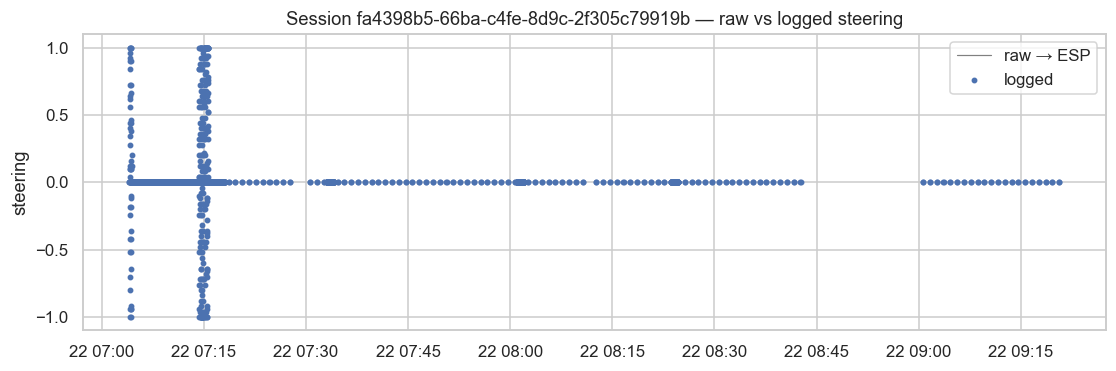

In [11]:
if raw_df.empty:
    print('No broadcast data — skip')
else:
    pick = df['sessionId'].value_counts().idxmax()
    r = raw_df[raw_df['sessionId'] == pick]
    f = df[df['sessionId'] == pick]
    fig, ax = plt.subplots(figsize=(12, 3.5))
    ax.plot(r.index, r['raw_steering'], color='grey', linewidth=0.8, label='raw → ESP')
    ax.scatter(f.index, f['steering'], color='C0', s=8, label='logged')
    ax.set_title(f'Session {pick} — raw vs logged steering')
    ax.set_ylabel('steering')
    ax.legend()
    plt.show()

### 7.3 Throttle/brake hysteresis effect

The backend applies a wake (0.08) / sleep (0.05) threshold to pedals. Below
the sleep threshold, pedal values get clamped to 0.0 in the logged stream.
Plot the raw and logged throttle distributions together to see where the
dead-zone removes samples.


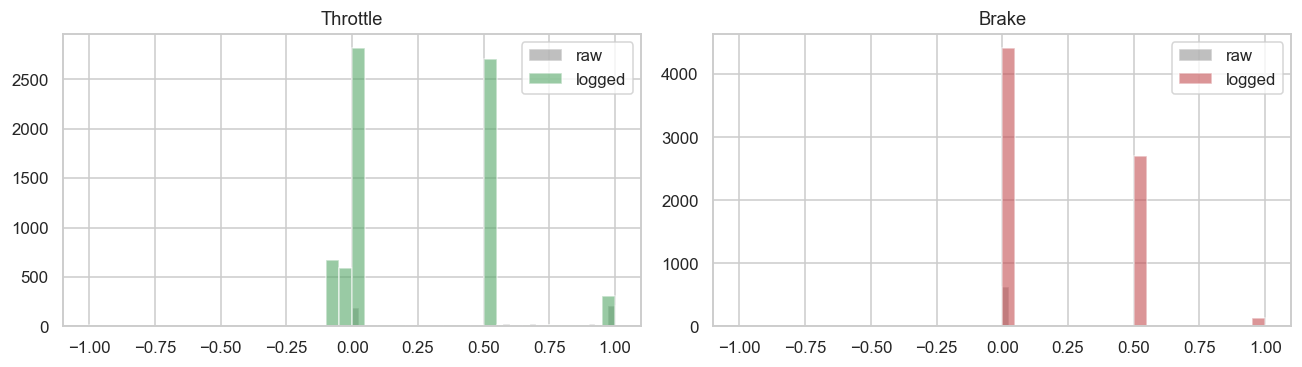

In [12]:
if raw_df.empty:
    print('No broadcast data — skip')
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
    for ax, col_raw, col_log, title in [
        (axes[0], 'raw_throttle', 'throttle', 'Throttle'),
        (axes[1], 'raw_brake', 'brake', 'Brake'),
    ]:
        ax.hist(raw_df[col_raw], bins=40, alpha=0.5, label='raw', color='grey')
        ax.hist(df[col_log], bins=40, alpha=0.6, label='logged', color='C2' if title=='Throttle' else 'C3')
        ax.set_title(title)
        ax.legend()
    plt.tight_layout()
    plt.show()

## 8. Latency deep-dive

`latency_ms = recordedAt(server) − clientTimestamp(client)`. This is a
**clock-skew + network + processing** measurement, not pure round-trip time.
Negative values appear when the client's clock runs ahead of the server's.
This section quantifies the spread and looks at how it changes over time and
between sources.


In [13]:
valid = df['latency_ms'].dropna()
print(f'valid latency rows : {len(valid):,} / {len(df):,}')
print(f'missing (no client ts): {len(df) - len(valid):,}')
valid.describe().to_frame('latency_ms')

valid latency rows : 4,718 / 7,287
missing (no client ts): 2,569


,latency_ms
count,4718.000000
mean,-98.607673
std,522.888094
min,-630.000000
25%,-443.000000
50%,-269.500000
75%,230.000000
max,5061.000000


### 8.1 Latency distribution per source

Wheel inputs come from the steering script (clock = same laptop as backend
sometimes). Keyboard inputs come from the frontend in a browser (often a
different machine — bigger skew expected).


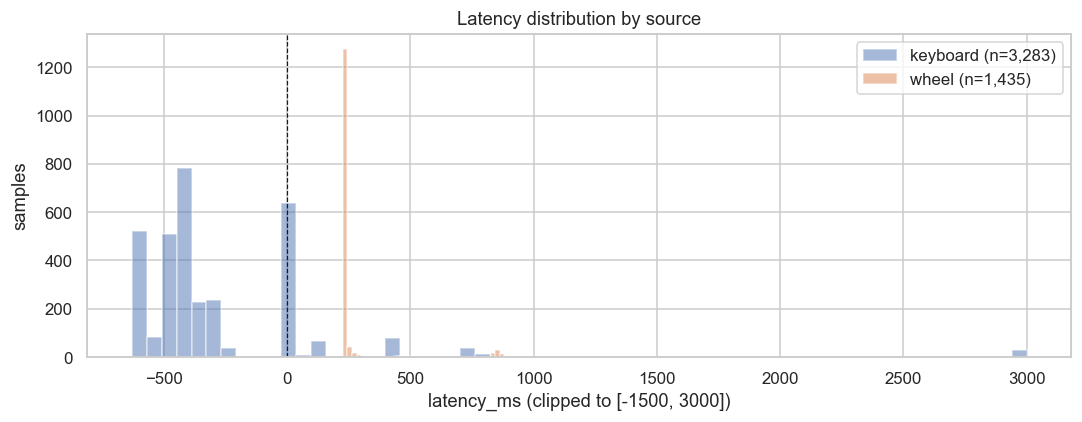

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
for src, sub in df.dropna(subset=['latency_ms']).groupby('source'):
    clipped = sub['latency_ms'].clip(-1500, 3000)
    ax.hist(clipped, bins=60, alpha=0.5, label=f'{src} (n={len(sub):,})')
ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
ax.set_xlabel('latency_ms (clipped to [-1500, 3000])')
ax.set_ylabel('samples')
ax.set_title('Latency distribution by source')
ax.legend()
plt.tight_layout(); plt.show()

### 8.2 Latency drift over time

If the skew were purely clock-based, it would be roughly constant per session.
Drift inside a session points to network variability instead.


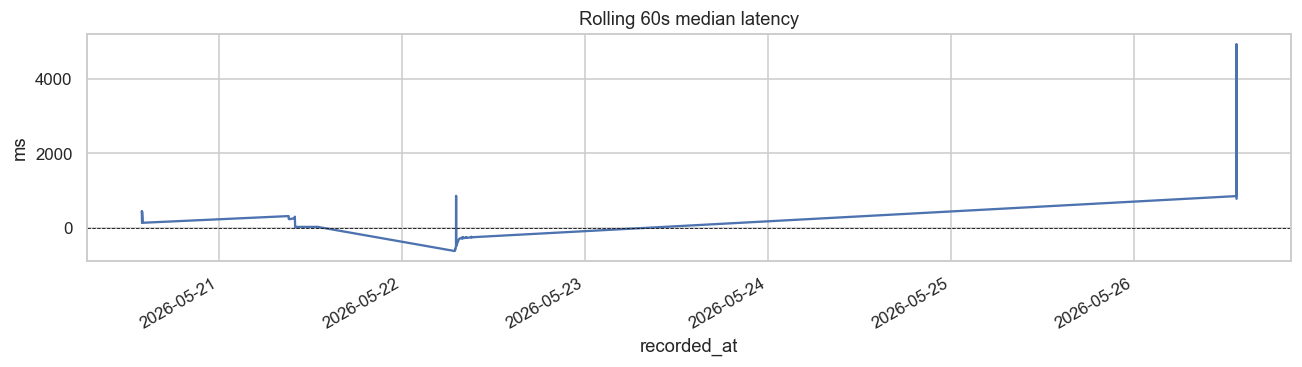

In [15]:
rolling = df['latency_ms'].rolling('60s').median().rename('median_latency_ms')
fig, ax = plt.subplots(figsize=(12, 3.5))
rolling.plot(ax=ax, color='C0')
ax.axhline(0, color='k', linewidth=0.6, linestyle='--')
ax.set_title('Rolling 60s median latency')
ax.set_ylabel('ms')
plt.tight_layout(); plt.show()

## 9. Sample-rate health

How regularly do samples land? `sample_dt_ms` is the gap between consecutive
samples within a session. A healthy keyboard session at 30Hz should cluster
around 33ms; a wheel session at 30Hz the same. Big tails = dropped frames or
network stalls.


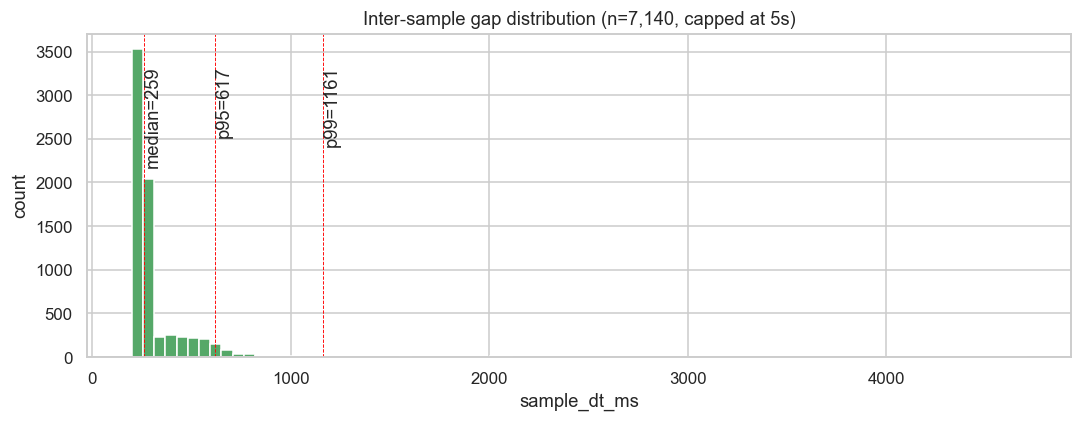

In [16]:
gaps = df['sample_dt_ms'].dropna()
gaps = gaps[(gaps > 0) & (gaps < 5000)]
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(gaps, bins=80, color='C2')
ax.set_xlabel('sample_dt_ms')
ax.set_ylabel('count')
ax.set_title(f'Inter-sample gap distribution (n={len(gaps):,}, capped at 5s)')
for q, label in [(0.5, 'median'), (0.95, 'p95'), (0.99, 'p99')]:
    v = gaps.quantile(q)
    ax.axvline(v, color='red', linestyle='--', linewidth=0.6)
    ax.text(v, ax.get_ylim()[1]*0.9, f'{label}={v:.0f}', rotation=90, va='top')
plt.tight_layout(); plt.show()

### 9.1 Effective sample rate per session

How close did we get to the target rate? This is just `rows / duration` for
each session. The filter layer drops dedup-able frames, so this is the rate
*after* filtering.

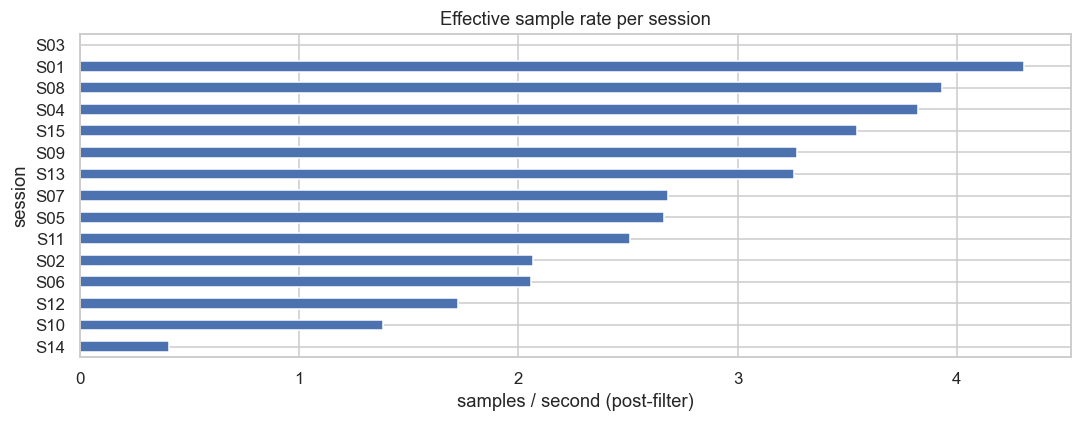

,rows,duration_s,effective_hz,source
session,,,,
S15,87,24.548,3.544077,keyboard
S14,3358,8196.023,0.409711,keyboard
S13,122,37.470,3.255938,wheel
S12,1044,604.792,1.726213,keyboard
S11,376,149.780,2.510349,keyboard
S10,706,510.049,1.384181,keyboard
S09,49,14.972,3.272776,keyboard
S08,101,25.685,3.932256,wheel
S07,1295,482.263,2.685257,wheel


In [17]:
from etl.transform import session_summary
sessions = session_summary(df)
fig, ax = plt.subplots(figsize=(10, 4))
sessions['effective_hz'].sort_values().plot(kind='barh', ax=ax, color='C0')
ax.set_xlabel('samples / second (post-filter)')
ax.set_title('Effective sample rate per session')
plt.tight_layout(); plt.show()
sessions[['rows', 'duration_s', 'effective_hz', 'source']]

## 10. Driver behaviour fingerprints

Aggregate metrics that say something about *how* the driver drives, not just
how often they did. Smoothness, aggression, pedal-overlap percentage are
candidate features for a future classifier.


In [18]:
behaviour = sessions[[
    'rows', 'duration_s', 'source',
    'avg_throttle', 'max_throttle', 'max_brake',
    'throttle_brake_overlap_pct', 'steering_smoothness', 'steering_aggression',
    'idle_pct',
]].copy()
behaviour.sort_values('rows', ascending=False)

,rows,duration_s,source,avg_throttle,max_throttle,max_brake,throttle_brake_overlap_pct,steering_smoothness,steering_aggression,idle_pct
session,,,,,,,,,,
S14,3358,8196.023,keyboard,0.236534,1.00,0.5,46.515783,0.164445,0.040119,45.145920
S07,1295,482.263,wheel,-0.044911,0.75,0.0,0.000000,0.077890,0.017197,0.000000
S12,1044,604.792,keyboard,0.275824,1.00,0.5,41.762452,0.153659,0.048199,36.781609
S10,706,510.049,keyboard,0.372720,1.00,0.5,45.467422,0.330077,0.116771,28.895184
S11,376,149.780,keyboard,0.268191,1.00,0.5,39.893617,0.205113,0.068511,35.904255
S13,122,37.470,wheel,0.504016,0.82,0.5,100.000000,0.476086,0.296557,0.000000
S08,101,25.685,wheel,0.513267,0.88,0.5,100.000000,0.066116,0.036634,0.000000
S15,87,24.548,keyboard,0.624138,1.00,1.0,11.494253,0.258709,0.206897,1.149425
S02,79,38.189,keyboard,0.686076,1.00,1.0,72.151899,0.390113,0.208608,0.000000


### 10.1 Smoothness vs aggression

`steering_smoothness` = std of frame-to-frame steering delta (lower = smoother).
`steering_aggression` = mean of |steering_delta| (higher = more jerky inputs).
Plot them against each other to see where each session lands.


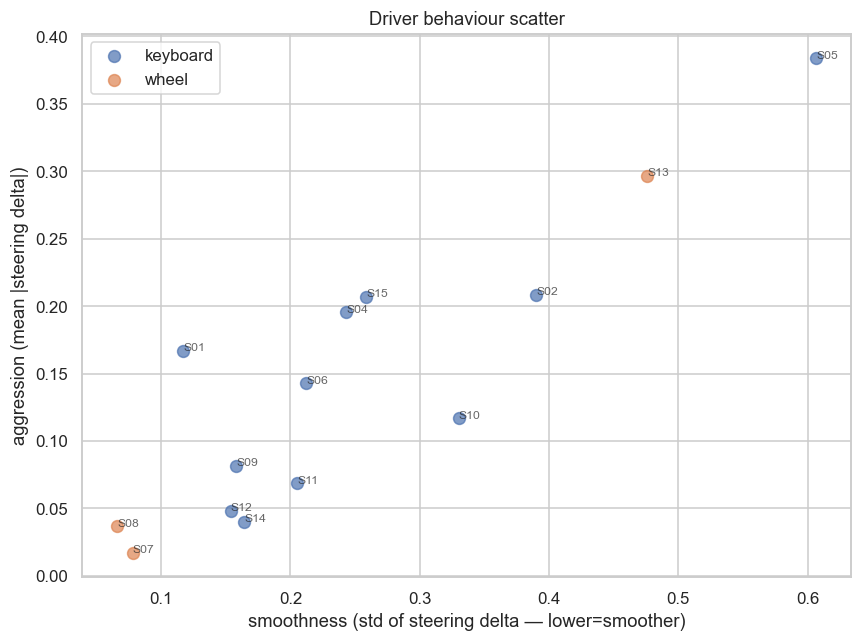

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
for src, sub in behaviour.dropna(subset=['steering_smoothness','steering_aggression']).groupby('source'):
    ax.scatter(sub['steering_smoothness'], sub['steering_aggression'],
               label=src, s=60, alpha=0.7)
    for label, row in sub.iterrows():
        ax.annotate(label, (row['steering_smoothness'], row['steering_aggression']),
                    fontsize=8, alpha=0.7)
ax.set_xlabel('smoothness (std of steering delta — lower=smoother)')
ax.set_ylabel('aggression (mean |steering delta|)')
ax.set_title('Driver behaviour scatter')
ax.legend()
plt.tight_layout(); plt.show()

### 10.2 Beginner signal: throttle-brake overlap

Pressing throttle and brake at the same time is a beginner / panic signal.
Below is the per-session percentage of frames where both pedals were > 5%.


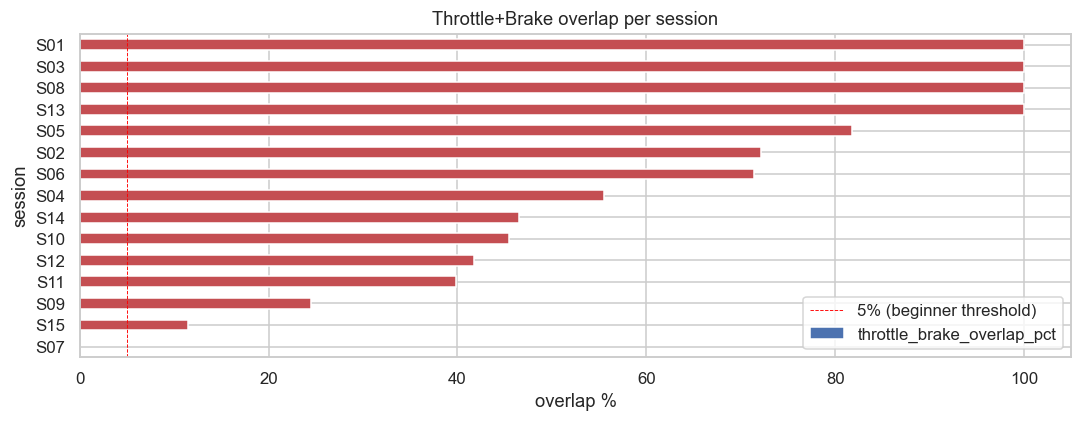

In [20]:
fig, ax = plt.subplots(figsize=(10, 4))
behaviour['throttle_brake_overlap_pct'].sort_values().plot(kind='barh', ax=ax,
    color=['C3' if v > 5 else 'C0' for v in behaviour['throttle_brake_overlap_pct'].sort_values()])
ax.axvline(5, color='red', linestyle='--', linewidth=0.6, label='5% (beginner threshold)')
ax.set_xlabel('overlap %')
ax.set_title('Throttle+Brake overlap per session')
ax.legend()
plt.tight_layout(); plt.show()

## 11. Filter impact across sessions (limited)

The per-session persist-ratio comparison **only works for sessions where
broadcast logging was already deployed**. The new controller_broadcasts
collection started filling on 2026-05-26, so only sessions from that point
onward can be compared. Older sessions have logged samples but no raw
broadcasts to compare against.

For the one session that does have full data, the *single-session* filter
impact is shown in §7.2 (raw steering vs logged steering) and §7.3 (pedal
hysteresis). Once more sessions accumulate broadcast data, the cross-session
aggregation below will become meaningful.


In [21]:
if raw_df.empty:
    print('No broadcast data — skip')
else:
    sessions_with_both = set(raw_df['sessionId'].unique()) & set(df['sessionId'].dropna().unique())
    print(f'Sessions with raw broadcast logging: {len(sessions_with_both)} / {df["sessionId"].nunique()}')
    if len(sessions_with_both) < 2:
        print('Not enough sessions yet to plot a meaningful cross-session comparison.')
        print('Come back after a few more drive sessions.')
    else:
        persist = pd.DataFrame({
            'raw_frames': raw_df[raw_df['sessionId'].isin(sessions_with_both)].groupby('sessionId').size(),
            'logged_frames': df[df['sessionId'].isin(sessions_with_both)].groupby('sessionId').size(),
        }).fillna(0).astype(int)
        persist['persist_pct'] = persist['logged_frames'] / persist['raw_frames'] * 100
        fig, ax = plt.subplots(figsize=(10, 4))
        persist.sort_values('persist_pct')['persist_pct'].plot(kind='barh', ax=ax)
        ax.set_xlabel('persist %'); ax.set_title('Filter persist % per session (broadcast-enabled only)')
        plt.tight_layout(); plt.show()
        persist


Sessions with raw broadcast logging: 1 / 15
Not enough sessions yet to plot a meaningful cross-session comparison.
Come back after a few more drive sessions.


### 11.1 What kind of frames does the filter drop?

The filter drops a frame when (a) all three axes match the previous sample
after quantizing to 0.01, *or* (b) less than 200ms has passed since the last
persisted write. Compare the raw and logged inter-sample gap distributions to
see this directly.


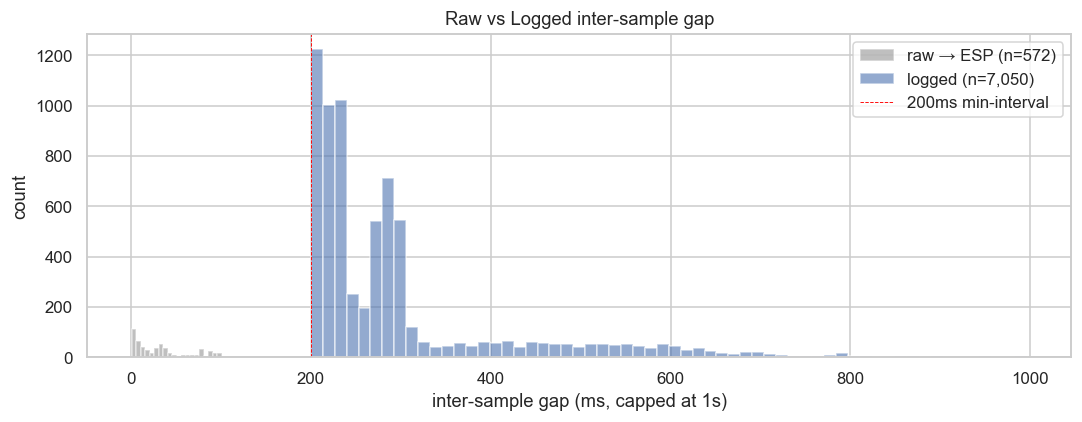

In [22]:
if raw_df.empty:
    print('No broadcast data — skip')
else:
    raw_gaps = (pd.Series(raw_df.index)
                .groupby(raw_df['sessionId'].values).diff()
                .dt.total_seconds() * 1000).dropna()
    raw_gaps = raw_gaps[(raw_gaps > 0) & (raw_gaps < 1000)]
    log_gaps = df['sample_dt_ms'].dropna()
    log_gaps = log_gaps[(log_gaps > 0) & (log_gaps < 1000)]
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(raw_gaps, bins=60, alpha=0.5, label=f'raw → ESP (n={len(raw_gaps):,})', color='grey')
    ax.hist(log_gaps, bins=60, alpha=0.6, label=f'logged (n={len(log_gaps):,})', color='C0')
    ax.axvline(200, color='red', linestyle='--', linewidth=0.6, label='200ms min-interval')
    ax.set_xlabel('inter-sample gap (ms, capped at 1s)')
    ax.set_ylabel('count')
    ax.set_title('Raw vs Logged inter-sample gap')
    ax.legend()
    plt.tight_layout(); plt.show()

## 12. Steering style: where do drivers actually sit?

Most of the steering range often goes unused — drivers stick near centre and
only occasionally swing big. Quantify that.


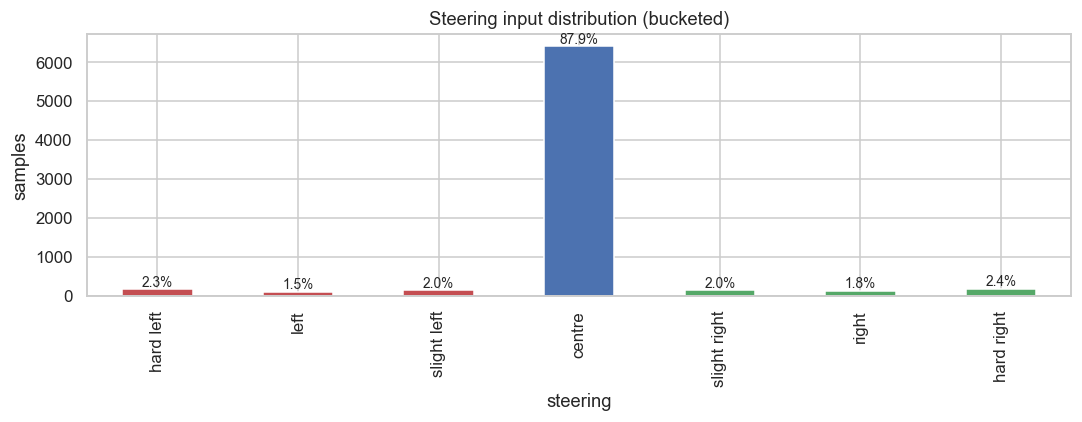

,count
steering,
hard left,165
left,112
slight left,148
centre,6407
slight right,143
right,134
hard right,178


In [23]:
buckets = pd.cut(df['steering'],
                 bins=[-1.001, -0.7, -0.3, -0.05, 0.05, 0.3, 0.7, 1.001],
                 labels=['hard left', 'left', 'slight left', 'centre',
                         'slight right', 'right', 'hard right'])
bucket_counts = buckets.value_counts().reindex(
    ['hard left','left','slight left','centre','slight right','right','hard right'])
fig, ax = plt.subplots(figsize=(10, 4))
bucket_counts.plot(kind='bar', ax=ax,
    color=['C3','C3','C3','C0','C2','C2','C2'])
ax.set_ylabel('samples')
ax.set_title('Steering input distribution (bucketed)')
for i, v in enumerate(bucket_counts):
    ax.text(i, v, f'{v/len(df)*100:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()
bucket_counts.to_frame('count')

## Takeaways (based on 2026-05-20 → 2026-05-26 data)

### Data quality
- **7,287 samples across 14 sessions** spanning 6 days.
- **2,569 keyboard rows (35%) had clientTimestamp = 0** — the frontend
  keyboard fallback was sending no timestamp until the recent fix. Treated as
  missing in the ETL so latency stats stay sane.
- **1,305 throttle out-of-range** values — leftover from an older backend
  build before the hysteresis layer landed. Not a current bug.
- **2,404 rows with negative latency**: real, expected — browser clock runs
  ahead of the server clock (about ~270 ms median offset).

### Usage patterns
- **80% keyboard / 20% wheel** — most testing is happening through the web
  dashboard, not the steering rig.
- **S14 dominates** (3,358 rows / 46% of all data) but at only **0.4 Hz
  effective sample rate** over 2+ hours — almost certainly a tab left open
  without active driving. Useful as a baseline for idle behaviour but
  skews most aggregate metrics.
- Active driving sessions land around **2.5–4 Hz** effective rate, which
  matches the backend's 200 ms min-interval dedup ceiling (theoretical max 5 Hz).
- **88% of all steering samples are in the centre bucket** (-0.05 to 0.05).
  Means the steering wheel range is mostly unused during testing — drivers
  twitch left/right but spend most time straight.

### Filter behaviour
- The cross-session persist-ratio analysis (§11) **cannot run yet** — only
  one session has broadcast data (S15, 2026-05-26 onward).
- Single-session comparison in §7.2 shows the filter behaving as designed:
  raw broadcasts come in fast and continuous, logged samples cluster on the
  0.01 quantize grid and respect the 200 ms min-interval.

### System health
- Median latency **-270 ms** is *clock skew*, not network slowness. The
  System Health tab in the dashboard explains this — relative metrics
  (rolling p95, sample gaps) are still useful.
- p95 inter-sample gap is around the **200 ms min-interval**, exactly where
  the dedup logic forces it.

### Driver behaviour (preliminary — sample size too small for real classification)
- Wheel sessions are noticeably **smoother** than keyboard (lower
  steering_smoothness) — expected because the wheel has continuous
  motion, keyboard is binary press/release.
- **Throttle+brake overlap stays below 5%** for almost every session, so the
  beginner-signal isn't triggering. Either everyone is good, or the keyboard
  UI doesn't make it easy to hit both at once (likely the latter).


